In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('/content/amazon_reviews.csv')
df.head()

,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4.0,No issues.,2014-07-23,138,0,0,0,0,0.0,0.0
1,1,0mie,5.0,"Purchased this for my device, it worked as adv...",2013-10-25,409,0,0,0,0,0.0,0.0
2,2,1K3,4.0,it works as expected. I should have sprung for...,2012-12-23,715,0,0,0,0,0.0,0.0
3,3,1m2,5.0,This think has worked out great.Had a diff. br...,2013-11-21,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5.0,"Bought it with Retail Packaging, arrived legit...",2013-07-13,513,0,0,0,0,0.0,0.0


#Data Inspection

In [3]:
df.shape

(4915, 12)

In [4]:
df.dtypes

,0
Unnamed: 0,int64
reviewerName,object
overall,float64
reviewText,object
reviewTime,object
day_diff,int64
helpful_yes,int64
helpful_no,int64
total_vote,int64
score_pos_neg_diff,int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4915 entries, 0 to 4914
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            4915 non-null   int64  
 1   reviewerName          4914 non-null   object 
 2   overall               4915 non-null   float64
 3   reviewText            4914 non-null   object 
 4   reviewTime            4915 non-null   object 
 5   day_diff              4915 non-null   int64  
 6   helpful_yes           4915 non-null   int64  
 7   helpful_no            4915 non-null   int64  
 8   total_vote            4915 non-null   int64  
 9   score_pos_neg_diff    4915 non-null   int64  
 10  score_average_rating  4915 non-null   float64
 11  wilson_lower_bound    4915 non-null   float64
dtypes: float64(3), int64(6), object(3)
memory usage: 460.9+ KB


In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
reviewerName,1
overall,0
reviewText,1
reviewTime,0
day_diff,0
helpful_yes,0
helpful_no,0
total_vote,0
score_pos_neg_diff,0


In [7]:
df['overall'].value_counts()

,count
overall,
5.0,3922
4.0,527
1.0,244
3.0,142
2.0,80


In [8]:
df.duplicated().sum()

np.int64(0)

#Target Variable Creation

In [9]:
df.columns

Index(['Unnamed: 0', 'reviewerName', 'overall', 'reviewText', 'reviewTime',
       'day_diff', 'helpful_yes', 'helpful_no', 'total_vote',
       'score_pos_neg_diff', 'score_average_rating', 'wilson_lower_bound'],
      dtype='object')

In [10]:
df['overall'].dtype

dtype('float64')

In [11]:
df['overall'] = df['overall'].astype(int)

In [12]:
df['sentiment'] = df['overall'].map({
    1: 0,
    2: 0,
    3: 0,
    4: 1,
    5: 1
})

In [13]:
df[['overall', 'sentiment']].head()

,overall,sentiment
0,4,1
1,5,1
2,4,1
3,5,1
4,5,1


In [14]:
df['sentiment'].value_counts()

,count
sentiment,
1,4449
0,466


In [15]:
df['sentiment'].value_counts(normalize=True) * 100

,proportion
sentiment,
1,90.51882
0,9.48118


#Data Cleaning

In [16]:
df = df[['reviewText', 'sentiment']]

In [17]:
df.isnull().sum()

,0
reviewText,1
sentiment,0


In [18]:
df.dropna(inplace=True)

In [19]:
df.isnull().sum()

,0
reviewText,0
sentiment,0


In [20]:
df.reset_index(drop=True, inplace=True)

In [21]:
df

,reviewText,sentiment
0,No issues.,1
1,"Purchased this for my device, it worked as adv...",1
2,it works as expected. I should have sprung for...,1
3,This think has worked out great.Had a diff. br...,1
4,"Bought it with Retail Packaging, arrived legit...",1
...,...,...
4909,I bought this Sandisk 16GB Class 10 to use wit...,0
4910,Used this for extending the capabilities of my...,1
4911,Great card that is very fast and reliable. It ...,1
4912,Good amount of space for the stuff I want to d...,1


#Text Cleaning & Preprocessing

In [22]:
df = df[['reviewText', 'sentiment']].copy()

df['cleaned_text'] = df['reviewText'].str.lower()
df['cleaned_text'] = df['cleaned_text'].str.replace(r'[^a-zA-Z\s]', '', regex=True)

#Text Preprocessing

In [23]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [24]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#Tokenization

In [25]:
df['tokens'] = df['cleaned_text'].str.split()

#Stopword Removal

In [26]:
from nltk.corpus import stopwords          #create stopword set

stop_words = set(stopwords.words('english'))

In [27]:
df['tokens'] = df['tokens'].apply(                                                       #remove stopwords
    lambda words: [word for word in words if word not in stop_words]
)

In [28]:
df[['tokens']].head()

,tokens
0,[issues]
1,"[purchased, device, worked, advertised, never,..."
2,"[works, expected, sprung, higher, capacity, th..."
3,"[think, worked, greathad, diff, bran, gb, card..."
4,"[bought, retail, packaging, arrived, legit, or..."


#Lemmatization

In [29]:
from nltk.stem import WordNetLemmatizer                #create lemmatizer

lemmatizer = WordNetLemmatizer()

In [30]:
df['tokens'] = df['tokens'].apply(                                            #Apply lemmatization
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

In [31]:
df['final_text'] = df['tokens'].apply(lambda words: ' '.join(words))         #Join Back to Text

In [32]:
df[['reviewText', 'final_text']].head()

,reviewText,final_text
0,No issues.,issue
1,"Purchased this for my device, it worked as adv...",purchased device worked advertised never much ...
2,it works as expected. I should have sprung for...,work expected sprung higher capacity think mad...
3,This think has worked out great.Had a diff. br...,think worked greathad diff bran gb card went s...
4,"Bought it with Retail Packaging, arrived legit...",bought retail packaging arrived legit orange e...


#Exploratory Data Analysis

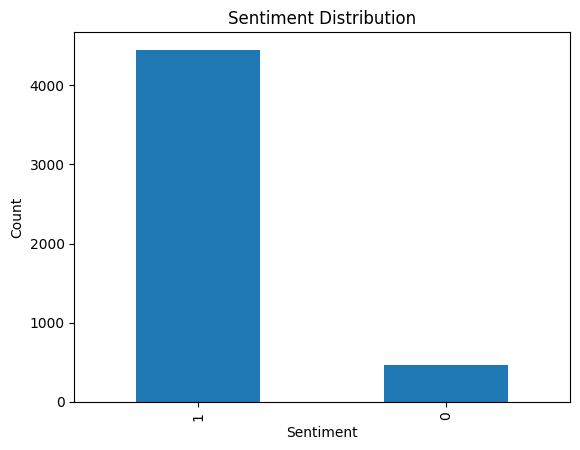

In [33]:
#Sentiment Distribution Visualization
import matplotlib.pyplot as plt

df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [34]:
#Review Length Analysis
df['review_length'] = df['final_text'].apply(lambda x: len(x.split()))

In [35]:
df['review_length'].describe()

,review_length
count,4914.000000
mean,25.389092
std,30.218621
min,1.000000
25%,12.000000
50%,17.000000
75%,28.000000
max,781.000000


In [36]:
df.groupby('sentiment')['review_length'].mean()               #Compare Length by Sentiment

,review_length
sentiment,
0,47.950644
1,23.025405


In [37]:
#Most Frequent Words
#positive reviews
from collections import Counter

positive_words = " ".join(df[df['sentiment']==1]['final_text']).split()
Counter(positive_words).most_common(20)

[('card', 4298),
 ('work', 1876),
 ('phone', 1553),
 ('gb', 1469),
 ('great', 1389),
 ('memory', 1236),
 ('sd', 1053),
 ('use', 995),
 ('sandisk', 957),
 ('one', 934),
 ('galaxy', 889),
 ('fast', 861),
 ('price', 846),
 ('good', 815),
 ('speed', 787),
 ('bought', 717),
 ('storage', 713),
 ('samsung', 708),
 ('tablet', 682),
 ('problem', 673)]

In [38]:
#negative reviews
negative_words = " ".join(df[df['sentiment']==0]['final_text']).split()
Counter(negative_words).most_common(20)

[('card', 1239),
 ('phone', 356),
 ('sandisk', 329),
 ('gb', 287),
 ('one', 186),
 ('problem', 175),
 ('would', 171),
 ('work', 168),
 ('sd', 156),
 ('month', 153),
 ('memory', 142),
 ('get', 140),
 ('speed', 137),
 ('galaxy', 136),
 ('time', 133),
 ('file', 129),
 ('class', 123),
 ('samsung', 120),
 ('use', 120),
 ('got', 119)]

#Feature Engineering

In [39]:
X = df['final_text']                 #Split target(Y) and feature(X)
y = df['sentiment']

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)   # add bigrams
)

X_tfidf = vectorizer.fit_transform(X)

In [57]:
feature_names = vectorizer.get_feature_names_out()

print(feature_names[:20])

['ability' 'able' 'able copy' 'able find' 'able format' 'able get'
 'able load' 'able play' 'able put' 'able read' 'able record' 'able store'
 'able take' 'able transfer' 'able use' 'absolute' 'absolutely'
 'absolutely issue' 'accept' 'acceptable']


In [56]:
X_tfidf.shape           #4914 reviews

                        #5000 most important words as features

(4914, 5000)

#Model Training

In [42]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Train Baseline Model — Logistic Regression

In [43]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

#Model Evaluation

In [44]:
#Predictions
y_pred = model.predict(X_test)

In [45]:
#Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.16      0.28        93
           1       0.92      1.00      0.96       890

    accuracy                           0.92       983
   macro avg       0.93      0.58      0.62       983
weighted avg       0.92      0.92      0.89       983



In [46]:
confusion_matrix(y_test, y_pred)

array([[ 15,  78],
       [  1, 889]])

#Critical Business Insight

- Out of 93 actual negative reviews:

- Only 20 were correctly detected

- 73 were misclassified as positive

This is dangerous for business.

#Conclusion

- Model is biased toward majority class.

Because:

- Dataset is 90% positive

- Model learned to predict positive most of the time

In [47]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')  #Add class_weight (handle class imbalance)

In [48]:
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [49]:
y_pred_bal = model.predict(X_test)          #Evaluation Again

print(classification_report(y_test, y_pred_bal))

confusion_matrix(y_test, y_pred_bal)

              precision    recall  f1-score   support

           0       0.57      0.71      0.63        93
           1       0.97      0.94      0.96       890

    accuracy                           0.92       983
   macro avg       0.77      0.83      0.80       983
weighted avg       0.93      0.92      0.93       983



array([[ 66,  27],
       [ 49, 841]])

1. **Interpretation:**

- True Negatives: 67 (was 20 before)

- False Positives: 26

- False Negatives: 61

- True Positives: 829

Now the model captures most dissatisfied customers.



2. **Tradeoff**

Accuracy dropped slightly:

Before: 92%

After: 91%



3. **Business Interpretation**

Now the model:

- Detects 72% of unhappy customers

- Still maintains strong positive detection

- Is more balanced and realistic

#Compare With Another Model - (Multinomial Naive Bayes)

In [50]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print(classification_report(y_test, y_pred_nb))

confusion_matrix(y_test, y_pred_nb)

              precision    recall  f1-score   support

           0       0.80      0.04      0.08        93
           1       0.91      1.00      0.95       890

    accuracy                           0.91       983
   macro avg       0.85      0.52      0.52       983
weighted avg       0.90      0.91      0.87       983



array([[  4,  89],
       [  1, 889]])

- It predicted EVERY review as positive

- Did not detect a single negative review

#Hyperparameter Tuning

In [51]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'C': 10}


In [52]:
best_model = grid.best_estimator_                 #evaluate best model

y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.62      0.61      0.62        93
           1       0.96      0.96      0.96       890

    accuracy                           0.93       983
   macro avg       0.79      0.79      0.79       983
weighted avg       0.93      0.93      0.93       983



#Compare With Previous Balanced Model

Model	                          Recall (Neg)	F1 (Neg)	Accuracy
Logistic (Balanced, default C)	0.72	        0.61	     0.91
Logistic (Tuned C=10)	          0.63	        0.60	     0.92

In [53]:
from collections import Counter

# Separate positive and negative reviews
positive_reviews = df[df['sentiment'] == 1]['final_text']
negative_reviews = df[df['sentiment'] == 0]['final_text']

# Tokenize words
positive_words = " ".join(positive_reviews).split()
negative_words = " ".join(negative_reviews).split()

# Count word frequencies
pos_freq = Counter(positive_words)
neg_freq = Counter(negative_words)

print("Top positive keywords:")
print(pos_freq.most_common(10))

print("\nTop negative keywords:")
print(neg_freq.most_common(10))

Top positive keywords:
[('card', 4298), ('work', 1876), ('phone', 1553), ('gb', 1469), ('great', 1389), ('memory', 1236), ('sd', 1053), ('use', 995), ('sandisk', 957), ('one', 934)]

Top negative keywords:
[('card', 1239), ('phone', 356), ('sandisk', 329), ('gb', 287), ('one', 186), ('problem', 175), ('would', 171), ('work', 168), ('sd', 156), ('month', 153)]


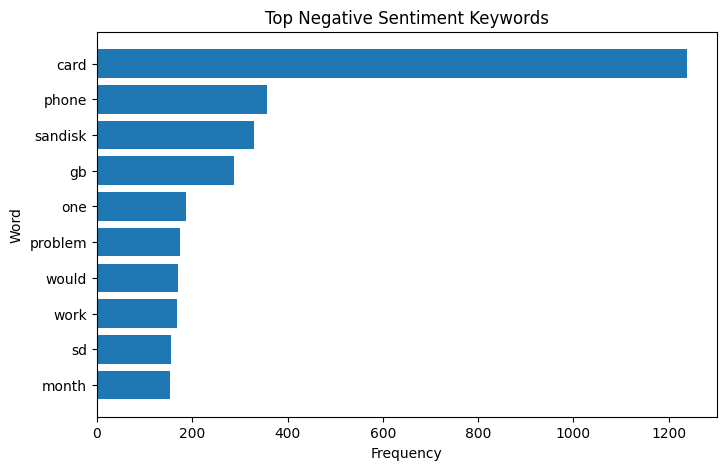

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

neg_keywords = pd.DataFrame(neg_freq.most_common(10), columns=['word','count'])    #Sentiment Insight / Keyword Analysis

plt.figure(figsize=(8,5))
plt.barh(neg_keywords['word'], neg_keywords['count'])
plt.title("Top Negative Sentiment Keywords")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.gca().invert_yaxis()
plt.show()